In [1]:
script = False
cluster = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from efficientnet_pytorch import EfficientNet

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import make_lupton_rgb

if(script):
    from tqdm import tqdm
else: 
    from tqdm.notebook import tqdm

plt.style.use('dark_background')

## ML Components 

In [2]:
num_workers = 0

transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

In [3]:
class ImageDataset(Dataset):
    """Dataset of Images, Data and Labels"""

    def __init__(self, images, data, labels, transform=None):
        """
        Create a PyTorch dataset from an array of images
		and an array of labels
        """
        super().__init__()
        self.images = images
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        
        new_image = np.empty((3, 45, 45))
        new_image[0], new_image[1], new_image[2] =  self.normalize_image(image)
        new_image = new_image.transpose(1,2,0)
        new_image = Image.fromarray(np.uint8(255*new_image)).convert("RGB")
        label = self.labels[idx]
        
        data_point = self.data.iloc[idx].to_dict()
        sample = {'image': self.transform(new_image), 'label': label, 'img': image, 'data': data_point}
        return sample
    
    def normalize_image(self, image):
        image_g = (image[0]-np.mean(image[0]))/ np.std(image[0])
        image_r = (image[1]-np.mean(image[1]))/ np.std(image[1])
        image_i = (image[2]-np.mean(image[2]))/ np.std(image[2])

        image_g = (image_g-np.min(image_g))/ (np.max(image_g) - np.min(image_g))
        image_r = (image_r-np.min(image_r))/ (np.max(image_r) - np.min(image_r))
        image_i = (image_i-np.min(image_i))/ (np.max(image_i) - np.min(image_i))
        return(image_i, image_r, image_g)

In [4]:
class EfficientNetClass(nn.Module):
    
    def __init__(self, n_classes, pretrained=False):
        super(EfficientNetClass, self).__init__()
        if(not cluster):
            self.model = EfficientNet.from_pretrained('efficientnet-b0',  num_classes=n_classes)
            torch.save(self.model.state_dict(), 'initial_model.pt')
        else:
            self.model = EfficientNet.from_name('efficientnet-b0',  num_classes=n_classes)
            self.model.load_state_dict(torch.load('initial_model.pt'))
            
    def forward(self, x):
        x = self.model(x)
        return x

In [5]:
model = EfficientNetClass(n_classes=14, pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

name = 'Exp/exp1/model_tmp.pt'#'model.pt'#'other.pt' 
model = torch.load(name, map_location=torch.device('cpu'))

Loaded pretrained weights for efficientnet-b0


## Rojas data

In [6]:
def make_plot_all(images, column_data, Q=9, stretch=40, minimum=(0,0,0)):
    for i in range(len(images)):
        if(i%8 == 0):
            plt.figure(figsize=(12,2))
            for j in range(8):
                if(i+j > len(images)-1): break
                plt.subplot(1,8,j+1)
                title = '{:.2f}'.format(column_data.iloc[i+j])
                plt.title(title)
                rgb = make_lupton_rgb(images[i+j][2], images[i+j][1], images[i+j][0], 
                                    Q=Q, stretch=stretch, minimum=minimum)
                plt.imshow(rgb, aspect='equal')
                plt.xticks([], [])
                plt.yticks([], []) 
            plt.show() 
    plt.close() 

Index(['COADD_OBJECT_ID', 'TILENAME', 'HPIX_4096', 'RA', 'DEC', 'Name',
       'Exp_score', 'n_Cand', 'rchi2', 'RE', 'U_RE', 'L_RE', 'qm', 'U_qm',
       'L_qm', 'PAm', 'U_PAm', 'L_PAm', 'gammaext', 'U_gammaext', 'L_gammaext',
       'phiext', 'U_phiext', 'L_phiext'],
      dtype='object')


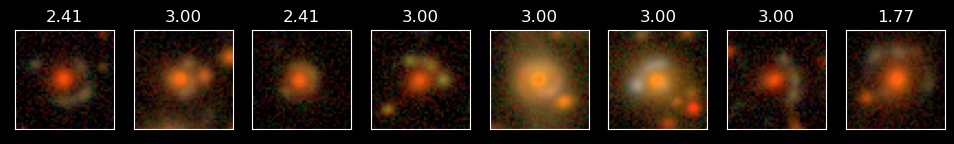

torch.Size([59, 4])


In [7]:
#Rojas candidates 
filepath = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_tocompare/final_files/'
hdu_list = fits.open(filepath + 'Rojas_DES.fits')
images = hdu_list[1].data.astype(np.float32)
data = Table(hdu_list[2].data).to_pandas() #Data is not complete here, just in the right sort
hdu_list.close()

data_tmp = data.sample(8)
print(data_tmp.columns)
images_tmp = images[data_tmp.index]
make_plot_all(images_tmp, data_tmp['Exp_score'])

labels_dataset = data.drop(['COADD_OBJECT_ID', 'TILENAME', 'HPIX_4096', 'RA', 'DEC', 'Name',
       'Exp_score', 'n_Cand', 'rchi2', 'U_RE', 'L_RE', 'U_qm', 'L_qm', 'U_PAm', 'L_PAm', 'gammaext', 
        'U_gammaext', 'L_gammaext', 'U_phiext', 'L_phiext'], axis = 1) #Keep: 'RE', 'qm', 'PAm'
labels_dataset = torch.tensor(labels_dataset.values, dtype=torch.float32)
print(labels_dataset.shape)

dataset = ImageDataset(images, data, labels_dataset, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=1, num_workers=num_workers, shuffle=True)

## Evaluating Performance

In [8]:
def testing_analysis(test_loader):
    predicted_data, true_data = pd.DataFrame(), pd.DataFrame()
    for i, sample in enumerate(tqdm(test_loader)):
        data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']

        output = model.forward(data)
        output = pd.DataFrame(output.detach().cpu().numpy())
        
        predicted_data = predicted_data.append(output)
        true_data = true_data.append(pd.DataFrame(target.cpu().numpy()))
        
    return(predicted_data, true_data)

In [9]:
predicted_data, true_data = testing_analysis(data_loader)

names = ['EINSTEIN_RADIUS', 'e1_lens', 'e2_lens', 'center_x_lens', 'center_y_lens', 'R_sersic_source_light',
       'n_sersic_source_light', 'e1_source_light', 'e2_source_light', 'center_x_source', 'center_y_source', 
        'R_sersic_lens_light', 'e1_lens_light', 'e2_lens_light']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
predicted_data.rename(columns=column_mapping, inplace=True)

  0%|          | 0/59 [00:00<?, ?it/s]

In [10]:
def q_theta_from_e1_e2(e1, e2):
    e = np.sqrt(e1**2 + e2**2)
    q = (1 - e) / (1 + e)
    theta = np.degrees(np.arctan2(e2, e1) / 2)
    return q, theta

q_list, phi_list = q_theta_from_e1_e2(predicted_data['e1_lens'], predicted_data['e2_lens'])
predicted_data['qm'], predicted_data['PAm'] = q_list, phi_list
predicted_data.rename(columns={'EINSTEIN_RADIUS': 'RE'}, inplace=True)

predicted_data.head()

,RE,e1_lens,e2_lens,center_x_lens,center_y_lens,R_sersic_source_light,n_sersic_source_light,e1_source_light,e2_source_light,center_x_source,center_y_source,R_sersic_lens_light,e1_lens_light,e2_lens_light,qm,PAm
0,2.516284,-0.040488,-0.029362,-0.012009,-0.019291,0.764615,3.711309,-0.133410,0.009820,0.511007,0.267828,1.651828,-0.076005,-0.079349,0.904737,-72.024940
0,3.546384,-0.140448,-0.163021,0.000444,-0.027853,0.909110,4.474451,0.025867,0.047021,0.044288,-0.357574,1.301280,-0.183376,0.034027,0.645849,-65.372963
0,5.319463,0.117859,0.004166,-0.057432,-0.042103,0.718560,5.223208,0.083905,0.019902,-0.144444,-0.602342,1.309016,-0.016584,0.034510,0.789017,1.012168
0,2.261206,-0.031738,-0.093056,-0.012599,-0.015080,0.809913,4.844642,0.013481,-0.054649,0.319526,-0.412460,1.057450,-0.134545,0.131471,0.820964,-54.416428
0,4.386183,0.101032,-0.014469,0.009263,0.036077,0.926043,5.091093,-0.063792,-0.049781,-0.170989,0.578832,1.876195,-0.066659,0.022773,0.814779,-4.075002


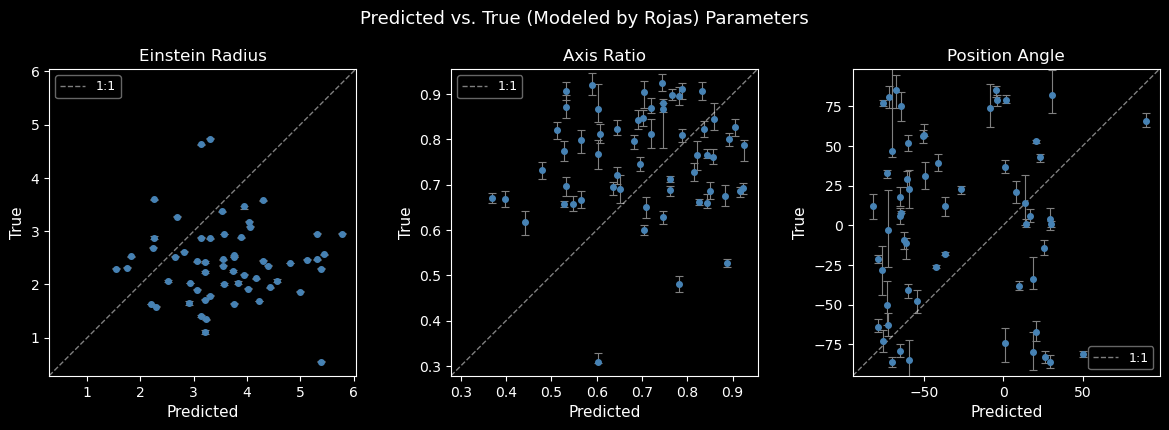

In [11]:
# I have three columns to compare: 'RE', 'qm', 'PAm'
titles = {'RE': 'Einstein Radius', 'qm': 'Axis Ratio', 'PAm': 'Position Angle'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, column in zip(axes, titles):
    yerr = [data['L_' + column], data['U_' + column]]
    ax.errorbar(predicted_data[column], data[column], yerr=yerr, fmt='o', markersize=4, color='steelblue',
        ecolor='gray', elinewidth=0.8, capsize=3, capthick=0.8, alpha=1., linewidth=0)

    # 1:1 reference line
    all_vals = np.concatenate([predicted_data[column], data[column]])
    lims = [all_vals.min(), all_vals.max()]
    margin = (lims[1] - lims[0]) * 0.05
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, 'w--', linewidth=1, alpha=0.5, label='1:1')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(titles[column], fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, framealpha=0.5)

plt.suptitle('Predicted vs. True (Modeled by Rojas) Parameters', fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure.pdf', bbox_inches='tight', dpi=300)
plt.show()